In [2]:
import pandas as pd

In [3]:
import sklearn as skl
import matplotlib as mpl
import seaborn as sb

In [4]:
df=pd.read_csv("housing_1.csv",index_col=0)

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17788,-121.83,37.36,22.0,3936.0,860.0,3508.0,877.0,4.2312,183800.0,<1H OCEAN
15637,-122.41,37.80,52.0,2892.0,751.0,1785.0,733.0,3.5746,350000.0,NEAR BAY
9674,-118.74,37.58,20.0,3301.0,779.0,1085.0,448.0,3.7315,159300.0,INLAND
14980,-117.01,32.71,20.0,3506.0,692.0,1977.0,668.0,2.9810,129100.0,NEAR OCEAN
2450,-119.55,36.51,46.0,1889.0,390.0,971.0,403.0,2.2132,76600.0,INLAND


In [6]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [7]:
df.shape[0]

19608

In [8]:
df.info

<bound method DataFrame.info of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
17788    -121.83     37.36                22.0       3936.0           860.0   
15637    -122.41     37.80                52.0       2892.0           751.0   
9674     -118.74     37.58                20.0       3301.0           779.0   
14980    -117.01     32.71                20.0       3506.0           692.0   
2450     -119.55     36.51                46.0       1889.0           390.0   
...          ...       ...                 ...          ...             ...   
11284    -117.96     33.78                35.0       1330.0           201.0   
11964    -117.43     34.02                33.0       3084.0           570.0   
5390     -118.38     34.03                36.0       2101.0           569.0   
860      -121.96     37.58                15.0       3575.0           597.0   
15795    -122.42     37.77                52.0       4226.0          1315.0   

       population  

# Etape 1 :  Découverte, analyse et préparation de la donnée
## Exploration des données

### 1.Comprendre les données

Il y a 19608 biens détaillé sur 10 colonne.

La position des biens ( longitude / latitude)=>
l'age du bien
le nombre total de piece
nombre de chambre
nb de personne dans le bien
nombre de propriétaire
revenue médian des locataire
prix médian d'un bien.



In [9]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19608.000000,19608.000000,19608.000000,19608.000000,19608.000000,19608.000000,19608.000000,19608.000000,19608.000000
mean,-119.574936,35.637851,28.621940,2636.594553,538.310231,1426.398715,499.810180,3.866285,206668.651112
std,2.005336,2.137203,12.602572,2186.486777,422.371597,1137.794613,383.502515,1.892546,115333.262317
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,786.000000,280.000000,2.560825,119300.000000
50%,-118.500000,34.260000,29.000000,2126.000000,435.000000,1166.000000,410.000000,3.534800,179550.000000
75%,-118.010000,37.720000,37.000000,3144.000000,647.000000,1726.000000,605.000000,4.742725,264600.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
df.max()

longitude                -114.31
latitude                   41.95
housing_median_age          52.0
total_rooms              39320.0
total_bedrooms            6445.0
population               35682.0
households                6082.0
median_income            15.0001
median_house_value      500001.0
ocean_proximity       NEAR OCEAN
dtype: object

### 2.description des donnée
a. il y a jusqu'a 25 % des biens qui ont un age inf ou= à 18ans
b. Le prix moyen d'un bien est de 206668.65 (j'imagine dollard car en californie)
c. il y a jusqu'a 25 % des biens qui ont un age sup à 37ans

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

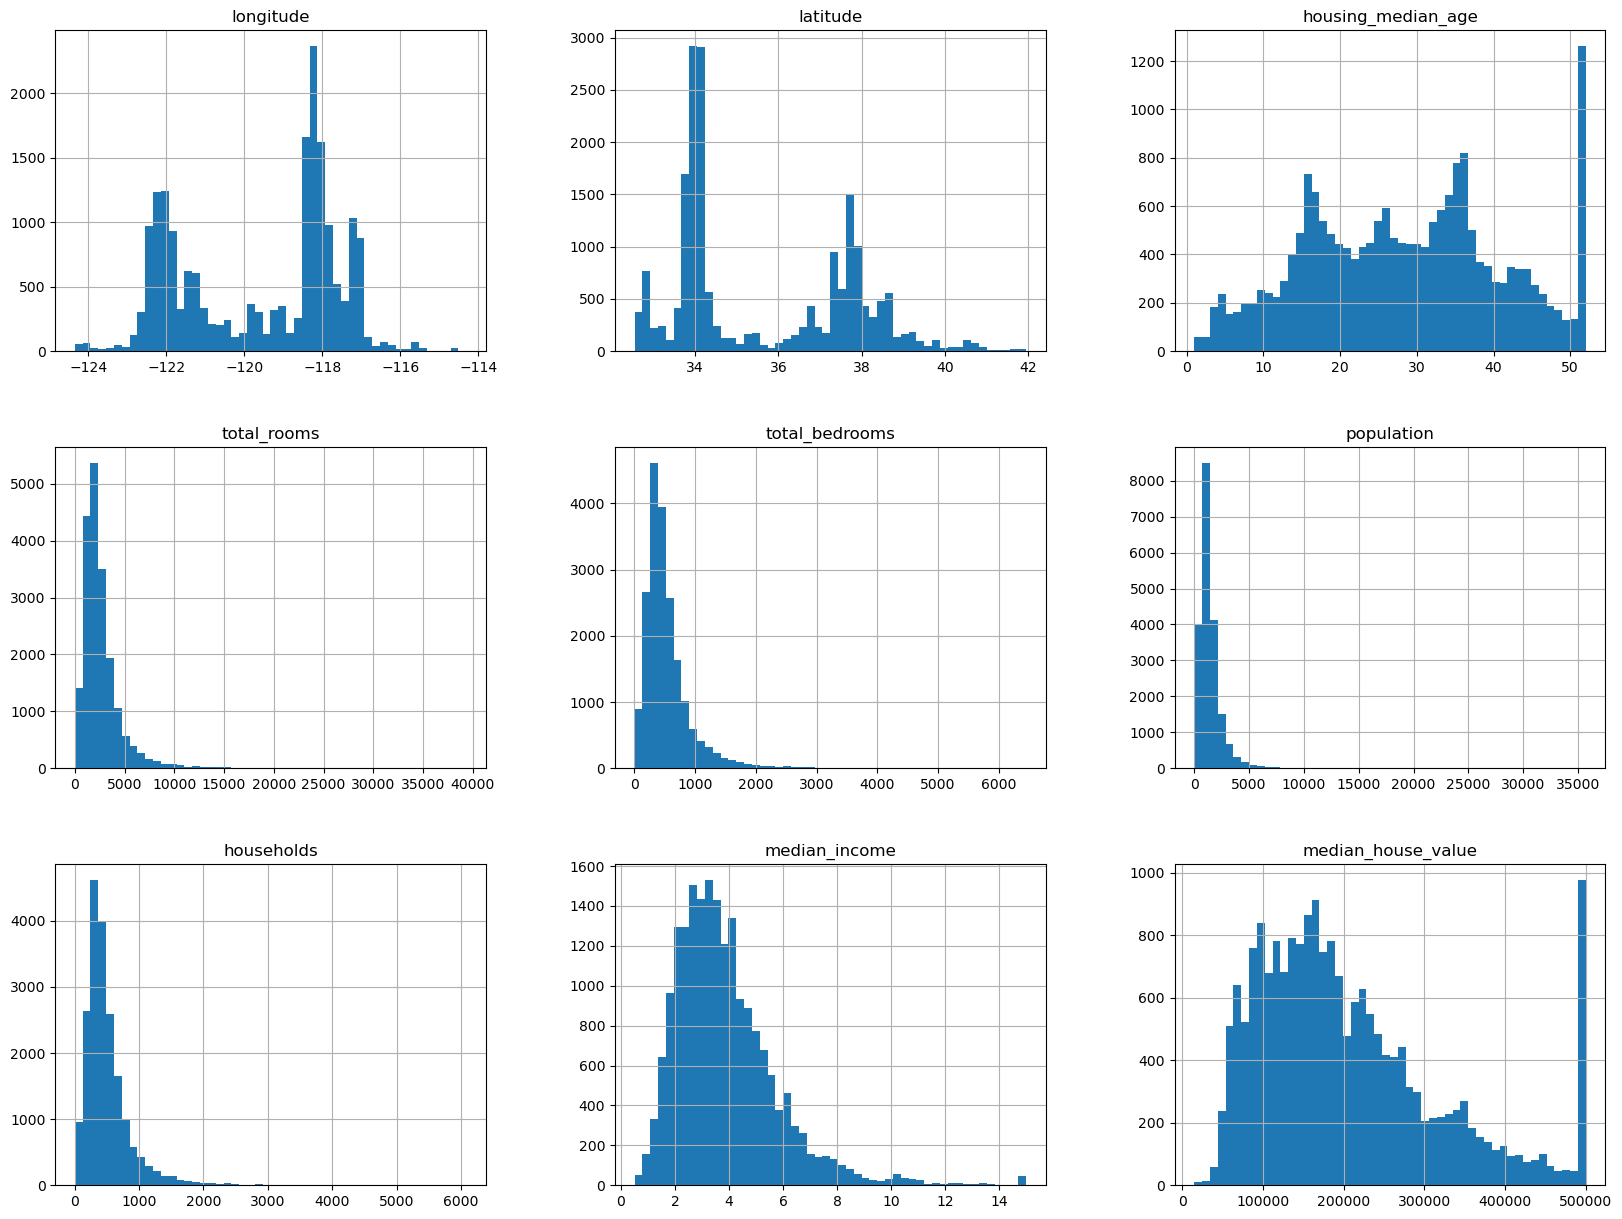

In [11]:
df.hist(bins=50,figsize=(20,15))

## 3.Histogramme
a. les plages de données mediane_income on représente les salaires moyens les personnes reporter entre 0 et 15 correspondant à 0K$jusqu'a 15k$ /mois.

b.  housing_median_age: il semble que cela correpond a une borne d'age de bien sup a 51ans (notre groupe ne veux pas vendre des biens de + de 50ans et à donc regroupé les établissement de + de 50ans dans cette borne.

median_house_value:idem pour cette option, notre groupe sais qu'il n'arrivera jamais a vendre un bien à plus de 500k $, ils ont donc regroupé dans une borne haute.   

<Axes: xlabel='longitude', ylabel='latitude'>

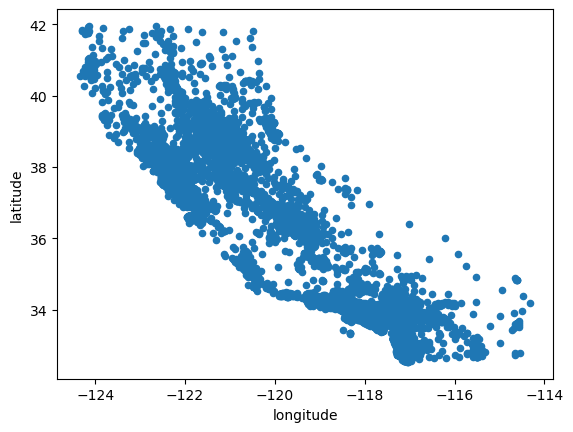

In [12]:
df.plot.scatter(x='longitude', y='latitude')

## 4. longitude,latitude

cela redessine la californie (on vois bien ou sont les grande aglomeration( les nuage de point les plus dense) et on vois bien que dans le dessert il y a beaucoup moins de biens vendu.

<Axes: xlabel='longitude', ylabel='latitude'>

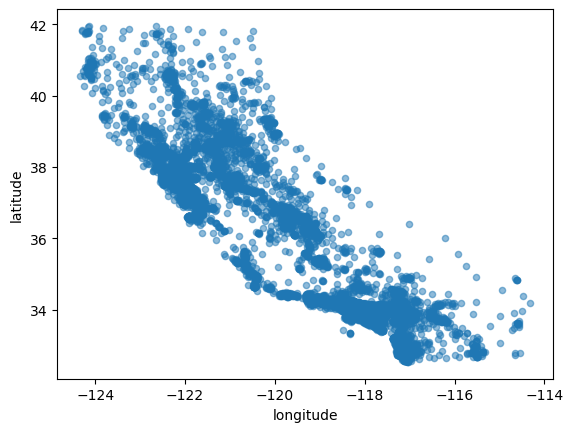

In [13]:
df.plot.scatter(x='longitude', y='latitude',alpha =0.5)

## 5 . Densité de données
Cela nous conforte dans l'idée que notre batch de donnée prend en compte beaucoup de bien situé dans les + grande ville de californi (LA,San francisco, san diego)

<Axes: xlabel='longitude', ylabel='latitude'>

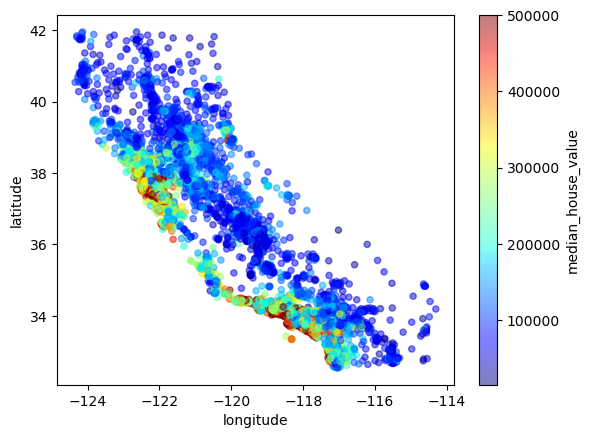

In [14]:
df.plot.scatter(x='longitude', y='latitude',c='median_house_value',cmap="jet",alpha =0.5)

## 6. carte de chaleur
On constate que les biens les plus cher se situ sur la cote et proche des grande ville ( je ne connais pas la map de la californie par coeur mais je dirai (san diego et LA "si j'avais regarder une carte)

<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

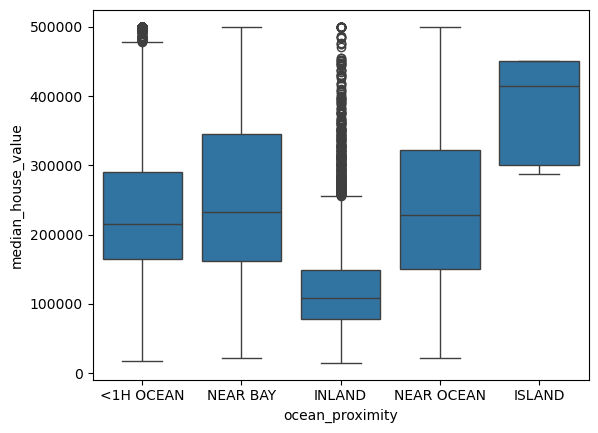

In [15]:
sb.boxplot(x=df['ocean_proximity'], y =df['median_house_value'])

In [16]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8665
INLAND        6243
NEAR OCEAN    2510
NEAR BAY      2185
ISLAND           5
Name: count, dtype: int64

## 7. Plus cher ?
les biens les plus chers se trouvent sur les iles,suivi par les bien proche de l'eau ( bay, ocean) et en derniere position les biens situe dans les terres)

## 8. Matrice de corrélation : 

Pour pouvoir le faire nous devons trasformer la colonne ocean proximity, nous allons donc considérer :
{1 = ISLAND, 2 = NEAR OCEAN , 3 = NEAR BAY, 4 = <1H OCEAN, 0 = INLAND}

In [17]:
df['ocean_proximity']= df['ocean_proximity'].replace(['ISLAND', '<1H OCEAN','NEAR BAY', 'INLAND', 'NEAR OCEAN'] , ['1','4','3','0','2'])



In [18]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
17788,-121.83,37.36,22.0,3936.0,860.0,3508.0,877.0,4.2312,183800.0,4
15637,-122.41,37.80,52.0,2892.0,751.0,1785.0,733.0,3.5746,350000.0,3
9674,-118.74,37.58,20.0,3301.0,779.0,1085.0,448.0,3.7315,159300.0,0
14980,-117.01,32.71,20.0,3506.0,692.0,1977.0,668.0,2.9810,129100.0,2
2450,-119.55,36.51,46.0,1889.0,390.0,971.0,403.0,2.2132,76600.0,0
...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,4
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,0
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,4
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,4


<Axes: >

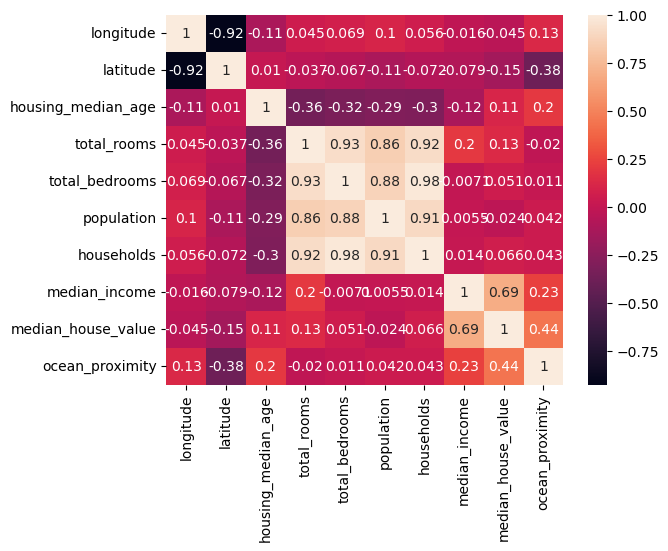

In [19]:
sb.heatmap(df.corr(), annot=True)

## 8. Matrice de corrélation :

On constate une forte corrélation:
 * entre le nombre de pièce et le nb de chambre, 
 * entre le nombre de personne avec le nombre de piece,
 * entre la longitude et la latitude
 * le nb de propriétaire et la population (+ il y a de personnes dans un régions au + il va y avoir de propriétaire )
 * la valeur du biens à une corrélation avec les revenue des personnes.


<Axes: xlabel='median_house_value', ylabel='median_income'>

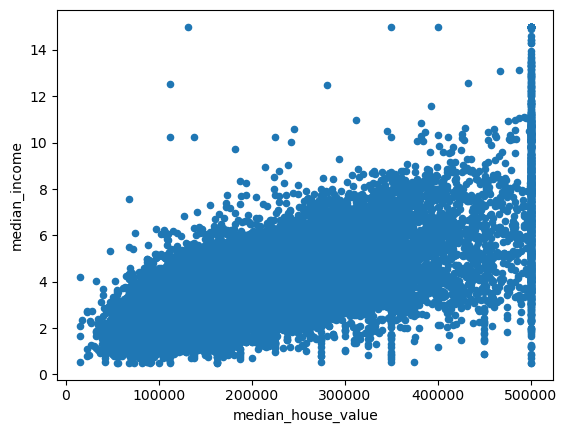

In [20]:
df.plot.scatter(x='median_house_value',y='median_income')

## 9. Corrélation salaire / valeur maison

Il semblerai qu'il y ai une corrélation entre les income des personnes et la valeur de leurs biens immobilier. 

# PREPARATION DES DONNEES

In [21]:
df['rooms_per_household']=df['total_rooms']/df['households']
df['bedrooms_per_room']=df['total_bedrooms'] / df['total_rooms']
df['population_per_household']=df['population']/df['households']

In [22]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
17788,-121.83,37.36,22.0,3936.0,860.0,3508.0,877.0,4.2312,183800.0,4,4.488027,0.218496,4.000000
15637,-122.41,37.80,52.0,2892.0,751.0,1785.0,733.0,3.5746,350000.0,3,3.945430,0.259682,2.435198
9674,-118.74,37.58,20.0,3301.0,779.0,1085.0,448.0,3.7315,159300.0,0,7.368304,0.235989,2.421875
14980,-117.01,32.71,20.0,3506.0,692.0,1977.0,668.0,2.9810,129100.0,2,5.248503,0.197376,2.959581
2450,-119.55,36.51,46.0,1889.0,390.0,971.0,403.0,2.2132,76600.0,0,4.687345,0.206458,2.409429
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,229200.0,4,6.129032,0.151128,3.032258
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,97800.0,0,6.868597,0.184825,3.904232
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,222100.0,4,3.986717,0.270823,3.332068
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,283500.0,4,6.395349,0.166993,3.178891


<Axes: >

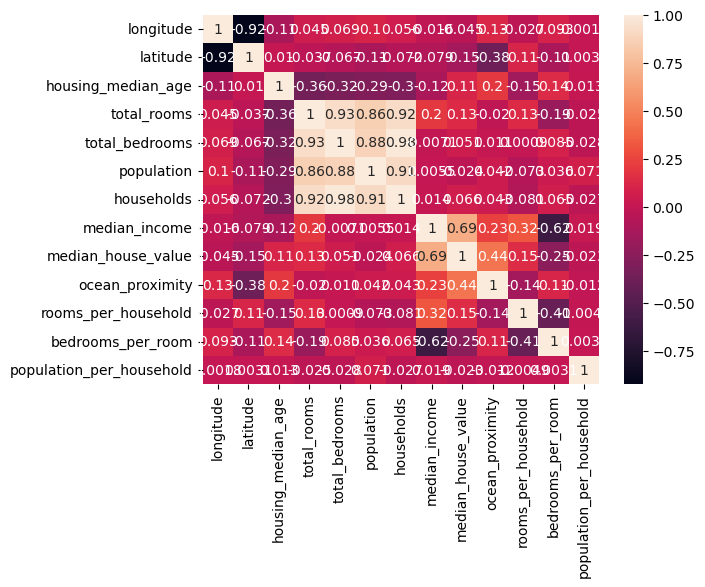

In [23]:
sb.heatmap(df.corr(), annot=True)

##1.Corrélation entre les nouvelle variable.
Il semble y avoir une corrélation négative entre le nombre de chambre par piece et la rentrée d'argent 

In [24]:
df.isnull().any()

longitude                   False
latitude                    False
housing_median_age          False
total_rooms                 False
total_bedrooms              False
population                  False
households                  False
median_income               False
median_house_value          False
ocean_proximity             False
rooms_per_household         False
bedrooms_per_room           False
population_per_household    False
dtype: bool

## 3.Valeur nulle? 
Il n'y a pas de valeur nulle dans notre data set.


## 4. Séparation des données

In [25]:
from sklearn.model_selection import train_test_split
X=df.drop('median_house_value', axis=1)
y = df[['median_house_value']]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [26]:
y

,median_house_value
17788,183800.0
15637,350000.0
9674,159300.0
14980,129100.0
2450,76600.0
...,...
11284,229200.0
11964,97800.0
5390,222100.0
860,283500.0


In [27]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
17788,-121.83,37.36,22.0,3936.0,860.0,3508.0,877.0,4.2312,4,4.488027,0.218496,4.000000
15637,-122.41,37.80,52.0,2892.0,751.0,1785.0,733.0,3.5746,3,3.945430,0.259682,2.435198
9674,-118.74,37.58,20.0,3301.0,779.0,1085.0,448.0,3.7315,0,7.368304,0.235989,2.421875
14980,-117.01,32.71,20.0,3506.0,692.0,1977.0,668.0,2.9810,2,5.248503,0.197376,2.959581
2450,-119.55,36.51,46.0,1889.0,390.0,971.0,403.0,2.2132,0,4.687345,0.206458,2.409429
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,4,6.129032,0.151128,3.032258
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,0,6.868597,0.184825,3.904232
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,4,3.986717,0.270823,3.332068
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,4,6.395349,0.166993,3.178891


In [28]:
X.isnull().any()

longitude                   False
latitude                    False
housing_median_age          False
total_rooms                 False
total_bedrooms              False
population                  False
households                  False
median_income               False
ocean_proximity             False
rooms_per_household         False
bedrooms_per_room           False
population_per_household    False
dtype: bool

In [29]:
X.dtypes

longitude                   float64
latitude                    float64
housing_median_age          float64
total_rooms                 float64
total_bedrooms              float64
population                  float64
households                  float64
median_income               float64
ocean_proximity              object
rooms_per_household         float64
bedrooms_per_room           float64
population_per_household    float64
dtype: object

In [30]:
X_train['ocean_proximity']= X_train['ocean_proximity'].replace(['ISLAND', '<1H OCEAN','NEAR BAY', 'INLAND', 'NEAR OCEAN'] , ['1','4','3','0','2'])

In [31]:
print(X_train['ocean_proximity'])

13055    0
5536     4
17462    2
5220     4
3155     0
        ..
17956    4
5795     4
8704     4
20483    4
16034    2
Name: ocean_proximity, Length: 15686, dtype: object


In [32]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.fit_transform(X_test)

In [34]:
X_train_scaled

array([[-0.85984918,  1.40211821, -0.52731504, ..., -0.07289397,
        -0.04701659, -0.03665612],
       [ 0.56258164, -0.78290596,  0.34603974, ...,  0.32781123,
        -0.64861617, -0.07764597],
       [-0.15865089, -0.56205405, -1.00369037, ..., -0.38663783,
        -0.05028457, -0.05474637],
       ...,
       [ 0.61767579, -0.83929368,  0.5842274 , ...,  0.05626102,
        -0.50195429, -0.03237346],
       [ 0.42234198, -0.6325387 , -0.84489859, ...,  0.17902191,
        -0.80175396,  0.0229925 ],
       [-1.45085917,  0.98390928,  1.45758218, ..., -0.432191  ,
         0.21024402, -0.00538463]])

# Étape 2 - Entrainement et fine-tunning
## 1. Linear regression

In [35]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression().fit(X_train_scaled,y_train)
R2= reg.score(X_train_scaled,y_train)
print(f"Le score de cette régression linéaire est de {R2}")

Le score de cette régression linéaire est de 0.6509242841665777


In [36]:
y_pred= reg.predict(X_test_scaled)

In [37]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Le mean Squared Error de ce model est de {mse}")
error_moy_mse=mse**0.5
print(f"L'erreur moyenne de ce model est de {error_moy_mse}")

Le mean Squared Error de ce model est de 4513925412.576233
L'erreur moyenne de ce model est de 67185.75304762337


Le résultat de la régression linéaire n'est pas trés bon au vue du R² car trés loin de 1 et une erreur d'estimation d'environ 67000. Le model pourai donc être meilleur avec un autre type de régression.

## 2. DecisionTree

In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
tree_reg = DecisionTreeRegressor(random_state=42).fit(X_train_scaled,y_train)

In [39]:
y_pred_tree=tree_reg.predict(X_test_scaled)

In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f"Le mean Squared Error de ce model est de {mse_tree}")

error_moy_mse_tree= np.sqrt(mean_squared_error(y_test, y_pred_tree))
print(f"L'erreur moyenne de ce model est de {error_moy_mse_tree}")

R2_tree= tree_reg.score(X_train_scaled,y_train)
print(f"Le score de cette régression linéaire est de {R2_tree}")

Le mean Squared Error de ce model est de 14048169636.77282
L'erreur moyenne de ce model est de 118524.97473854538
Le score de cette régression linéaire est de 1.0


on constate que le R2_tree(0.847) de cette méthode et encore + élevé que pour la regression lineaire(R²=0.651), Il est donc + interessant Mais à une erreur moyenne sur l'estimation de 71225

## 3.Ramdom forest normalisé

In [41]:
from sklearn.ensemble import RandomForestRegressor
rdmf_reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_scaled, y_train)

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [42]:
y_pred_rdmf = rdmf_reg.predict(X_test_scaled)

In [43]:
from sklearn.metrics import mean_squared_error
import numpy as np
mse_rdmf = mean_squared_error(y_test, y_pred_rdmf)
print(f"Le mean Squared Error de ce model est de {mse_rdmf}")

error_moy_mse_rdmf= np.sqrt(mean_squared_error(y_test, y_pred_rdmf))
print(f"L'erreur moyenne de ce model est de {error_moy_mse_rdmf}")

R2_rdmf= rdmf_reg.score(X_train_scaled,y_train)
print(f"Le score de cette régression linéaire est de {R2_rdmf}")

Le mean Squared Error de ce model est de 5786813183.250086
L'erreur moyenne de ce model est de 76071.1060998201
Le score de cette régression linéaire est de 0.9740355963602828


le score pour le ramdomforest est tres bon (tres proche de 1)  sur les valeurs normalisées est possède une esrreur d'estiamtion sup à 50 000$

## 4. Ramdon forest 

In [44]:
from sklearn.ensemble import RandomForestRegressor 
rdmf2_reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [45]:
y_pred_rdmf2 = rdmf2_reg.predict(X_test)

In [46]:
from sklearn.metrics import mean_squared_error
import numpy as np
mse_rdmf2 = mean_squared_error(y_test, y_pred_rdmf2)
print(f"Le mean Squared Error de ce model est de {mse_rdmf2}")

error_moy_mse_rdmf2= np.sqrt(mean_squared_error(y_test, y_pred_rdmf2))
print(f"L'erreur moyenne de ce model est de {error_moy_mse_rdmf2}")

R2_rdmf2= rdmf2_reg.score(X_train,y_train)
print(f"Le score de cette régression linéaire est de {R2_rdmf2}")

Le mean Squared Error de ce model est de 2418772142.986883
L'erreur moyenne de ce model est de 49181.01405000596
Le score de cette régression linéaire est de 0.9740300456431251


In [47]:
rdmf_reg.get_params(deep=True)

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

le model à un score identique que celui fait sur avec les données normalisé  et il a une erreur  d'estimation moyenne inf à 50 000

## 4. fine tunning

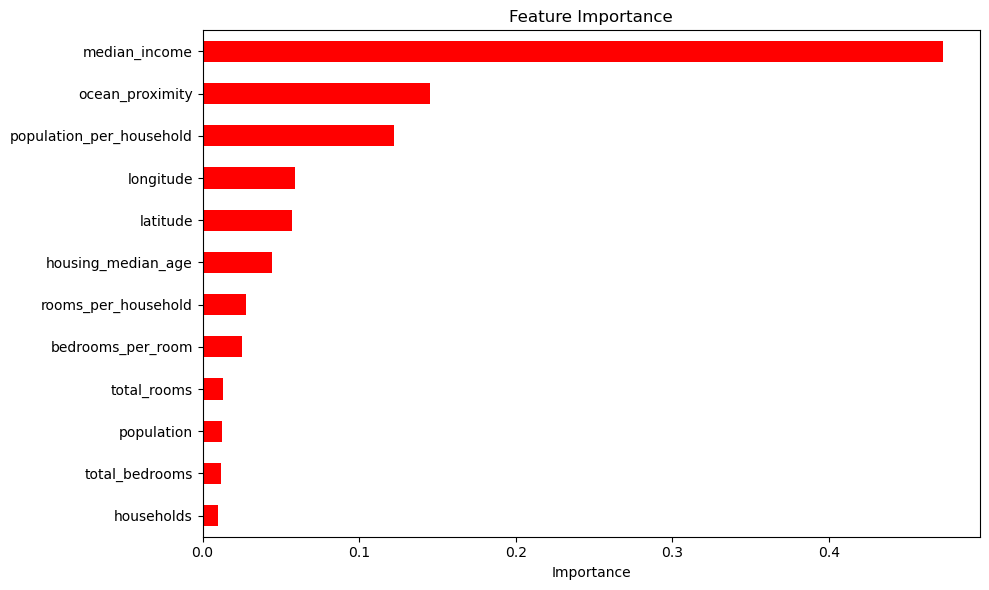

In [48]:
import matplotlib.pyplot as plt
importances = pd.Series(rdmf2_reg.feature_importances_, index=X.columns) 
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='r') 
plt.title("Feature Importance") 
plt.xlabel("Importance") 
plt.tight_layout() 
plt.show() 

on observe que le revenu moyen à un grande importance dans le model.

In [49]:
from sklearn.model_selection import GridSearchCV
param_grid = { 
'n_estimators': [100, 300], 
'max_depth': [None, 5, 10], 
'max_features': [3, 4, 6], 
'min_samples_leaf': [1, 3, 5], 
'bootstrap': [True] 
} 
grid_search = GridSearchCV(estimator=rdmf_reg, param_grid=param_grid, cv=5, n_jobs=1)

In [50]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarni

In [51]:
from sklearn.ensemble import RandomForestRegressor
rdmf2_reg= RandomForestRegressor(
    bootstrap = True,
    max_depth = None,
    max_features = 4,
    min_samples_leaf = 1,
    n_estimators = 300,
    random_state=42).fit(X_train, y_train)

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [52]:
y_pred_rdmf2=rdmf_reg.predict(X_test)

/opt/conda/envs/anaconda-ai-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [53]:
mse_rdmf2= mean_squared_error(y_test,y_pred_rdmf2)
print(f"Le mean Squared Error de ce model est de {mse_rdmf2}")
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"L'erreur moyenne sur une estimation de ce model est de {rmse}")
R2_rdmf2= rdmf2_reg.score(X_test,y_test)
print(f"Le R² de la méthode de ramdomforestclasifier est de {R2_rdmf2}")

Le mean Squared Error de ce model est de 47632419383.88538
L'erreur moyenne sur une estimation de ce model est de 67185.75304762337
Le R² de la méthode de ramdomforestclasifier est de 0.8227736782707882


Le score ce cette methode avec ces parameters est correct . Il est moins bon que le randomforest précedement testé mais l'erreur moyenne d'estimation à de nouveau diminué. nous allons donc utiliser ce model d'estimation

In [54]:
rdmf2_reg.get_params(deep=True)

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 4,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [55]:
joblib.dump(rf_molde, 'model_ramdomforest.joblib')

NameError: name 'joblib' is not defined